# Exercises XP: Text Preprocessing, NER, POS, and Word2Vec

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells marked TODO expect your code or analysis.

## What you will learn
- Clean and normalize raw reviews with tokenization, stopword removal, and lemmatization.
- Extract linguistic features with named entity recognition (NER) and part-of-speech (POS) tagging.
- Train a simple Word2Vec model and interpret its vector dimensions.
- Visualize word embeddings to reason about semantic neighborhoods.

## What you will create
- A `preprocess_text` function that lowercases, strips punctuation, removes stopwords, and lemmatizes.
- `perform_ner` and `perform_pos_tagging` helpers to analyze raw vs cleaned text.
- A Word2Vec model plus a helper to plot embeddings for inspection.

> Learning point
> Run the setup cells once, then progress through each exercise sequentially. Print intermediate results to verify every helper works before moving on.

## Setup · install libraries
Run once to install spaCy, nltk, gensim, and plotting utilities.

In [10]:
%pip install --quiet spacy nltk gensim matplotlib seaborn --upgrade

In [11]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 78.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [12]:
import nltk
from spacy.cli import download as spacy_download
import spacy

resources = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "tagsets",
]
for res in resources:
    nltk.download(res, quiet=True)

spacy_download("en_core_web_sm")

nlp = spacy.load("en_core_web_sm")
print("spaCy pipeline:", nlp.pipe_names)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Exercise 1 · Explore text preprocessing, NER, and POS tags

Here is the dataset you will reuse in every step.

In [13]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
raw_reviews = data['Review']
raw_reviews


["At McDonald's the food was ok and the service was bad.",
 'I would not recommend this Japanese restaurant to anyone.',
 'I loved this restaurant when I traveled to Thailand last summer.',
 'The menu of Loving has a wide variety of options.',
 "The staff was friendly and helpful at Google's employees restaurant.",
 'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
 'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
 'The sushi at Sushi Express is always fresh and flavorful.',
 'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
 'The dessert selection at Sweet Treats is to die for!']

### 1.1 Build `preprocess_text()`
Create a function that:
1. Lowercases and tokenizes text.
2. Removes punctuation tokens.
3. Removes English stopwords.
4. Applies a lemmatizer.
5. Returns the cleaned string joined by spaces.

Print the processed reviews to confirm every stage works.

In [14]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


# def preprocess_text(text: str) -> str:
#     """Lowercase, tokenize, strip punctuation, drop stopwords, and lemmatize a review."""
#     # TODO: tokenize the text (hint: nltk.word_tokenize)
#     # TODO: remove punctuation tokens
#     # TODO: filter out stopwords
#     # TODO: lemmatize remaining tokens
#     # TODO: join back into a single cleaned string
#     return None

def preprocess_text(text: str) -> str:
    """Lowercase, tokenize, strip punctuation, drop stopwords, and lemmatize a review."""

    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t not in string.punctuation]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)


### 1.2 Create a cleaned dataset
Apply `preprocess_text` to every review and keep both raw and cleaned versions side by side.

In [15]:
# TODO: apply preprocess_text to every review and keep both raw and cleaned versions

cleaned_reviews = [preprocess_text(review) for review in raw_reviews]

for raw, cleaned in zip(raw_reviews, cleaned_reviews):
    print(f"RAW: {raw}")
    print(f"CLEANED: {cleaned}\n")


RAW: At McDonald's the food was ok and the service was bad.
CLEANED: mcdonald 's food ok service bad

RAW: I would not recommend this Japanese restaurant to anyone.
CLEANED: would recommend japanese restaurant anyone

RAW: I loved this restaurant when I traveled to Thailand last summer.
CLEANED: loved restaurant traveled thailand last summer

RAW: The menu of Loving has a wide variety of options.
CLEANED: menu loving wide variety option

RAW: The staff was friendly and helpful at Google's employees restaurant.
CLEANED: staff friendly helpful google 's employee restaurant

RAW: The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
CLEANED: ambiance bella italia amazing pasta dish delicious

RAW: I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
CLEANED: terrible experience pizza hut pizza burnt service slow

RAW: The sushi at Sushi Express is always fresh and flavorful.
CLEANED: sushi sushi express always fresh flavorful

RAW

### 1.3 Named Entity Recognition (NER)
Create `perform_ner(text)` that returns `(entity, label_)` pairs using `en_core_web_sm`. Test it on a few reviews.

In [16]:
def perform_ner(text: str):
    """Return (entity, label) pairs found by spaCy."""
    # TODO: run the spaCy pipeline on the text
    # TODO: collect each entity text and its label_
    return None


### 1.4 Part-of-Speech tagging (POS)
Create `perform_pos_tagging(text)` using `nltk.pos_tag`. Test it on both raw and cleaned text.

Use `nltk.help.upenn_tagset('NN')` to recall tag meanings if needed.

In [17]:
from nltk import pos_tag, word_tokenize

def perform_pos_tagging(text: str):
    """Return POS tags for a given text."""
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities


### 1.5 Apply NER and POS on raw vs cleaned text
Compare outputs on the same entries to see how preprocessing affects tagging.

In [18]:
sample_texts = raw_reviews[:2]

print("NER on raw text")
# TODO: loop through sample_texts and print perform_ner results

print("\nNER on cleaned text")
for text in cleaned_reviews[:2]:
    print("TEXT:", text)
    print("NER:", perform_ner(text))
    print()

print("\nPOS tags on raw text")
for text in sample_texts:
    doc = nlp(text)
    pos_tags = [(token.text, token.pos_) for token in doc]
    print("TEXT:", text)
    print("POS:", pos_tags)
    print()

print("\nPOS tags on cleaned text")
for text in cleaned_reviews[:2]:
    doc = nlp(text)
    pos_tags = [(token.text, token.pos_) for token in doc]
    print("TEXT:", text)
    print("POS:", pos_tags)
    print()

NER on raw text

NER on cleaned text
TEXT: mcdonald 's food ok service bad
NER: None

TEXT: would recommend japanese restaurant anyone
NER: None


POS tags on raw text
TEXT: At McDonald's the food was ok and the service was bad.
POS: [('At', 'ADP'), ('McDonald', 'PROPN'), ("'s", 'PART'), ('the', 'DET'), ('food', 'NOUN'), ('was', 'AUX'), ('ok', 'ADJ'), ('and', 'CCONJ'), ('the', 'DET'), ('service', 'NOUN'), ('was', 'AUX'), ('bad', 'ADJ'), ('.', 'PUNCT')]

TEXT: I would not recommend this Japanese restaurant to anyone.
POS: [('I', 'PRON'), ('would', 'AUX'), ('not', 'PART'), ('recommend', 'VERB'), ('this', 'DET'), ('Japanese', 'ADJ'), ('restaurant', 'NOUN'), ('to', 'ADP'), ('anyone', 'PRON'), ('.', 'PUNCT')]


POS tags on cleaned text
TEXT: mcdonald 's food ok service bad
POS: [('mcdonald', 'PROPN'), ("'s", 'PART'), ('food', 'NOUN'), ('ok', 'INTJ'), ('service', 'NOUN'), ('bad', 'ADJ')]

TEXT: would recommend japanese restaurant anyone
POS: [('would', 'AUX'), ('recommend', 'VERB'), ('japane

## Exercise 2 · Plotting word embeddings

### 2.1 Train a Word2Vec model
Vectorize the preprocessed/tokenized dataset with `Word2Vec` from `gensim.models`. Reuse the cleaned text and adjust parameters like `vector_size`, `window`, and `sg`.

In [24]:
from gensim.models import Word2Vec

# TODO: ensure cleaned_reviews is defined from Exercise 1
# Tokenize on whitespace after preprocessing
tokenized_reviews = [review.split() for review in cleaned_reviews]

# TODO: train the Word2Vec model
w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1
)

### 2.2 Inspect embedding dimensions
Print and interpret the vector size and vocabulary size from the fitted model.

In [25]:
# TODO: print the vector size and vocabulary size of your model

print("Vector size:", w2v_model.vector_size)
print("Vocabulary size:", len(w2v_model.wv))

Vector size: 100
Vocabulary size: 56


### 2.3 Plot word embeddings
Complete `plot_word_embeddings(model)` to scatter-plot the first two dimensions of the learned vectors and annotate each point with its word. Discuss whether related words cluster together.

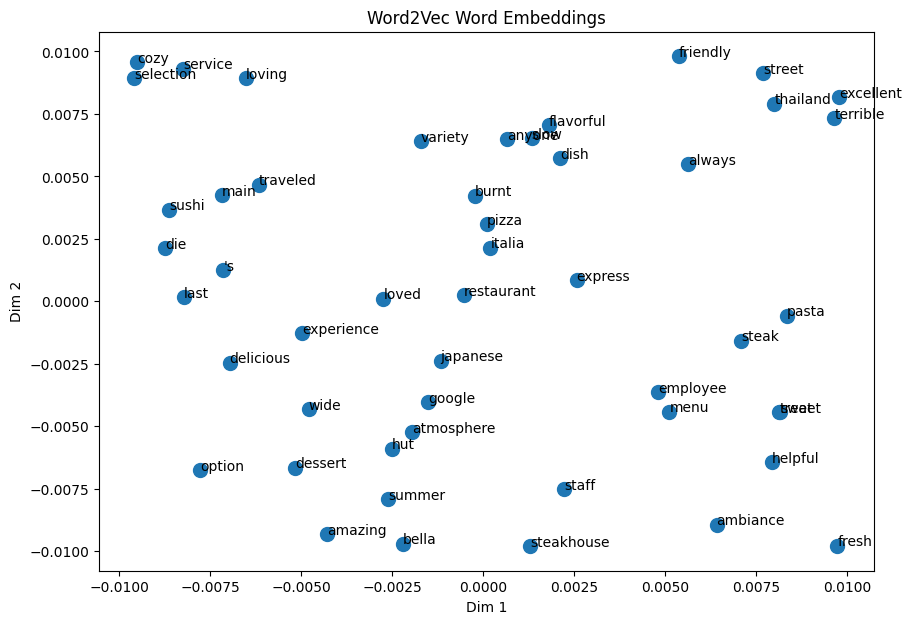

In [31]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

def plot_word_embeddings(model, words=None):
    if words is None:
        words = model.wv.index_to_key[:50]  # ограничили сразу

    words = [word for word in words if word in model.wv]

    x = [model.wv[word][0] for word in words]
    y = [model.wv[word][1] for word in words]

    plt.figure(figsize=(10, 7))
    plt.scatter(x, y, s=100)

    for word, x_pos, y_pos in zip(words, x, y):
        plt.annotate(word, (x_pos, y_pos))

    plt.title("Word2Vec Word Embeddings")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.show()

plot_word_embeddings(w2v_model)

### 2.4 Go further
- Experiment with different preprocessing (e.g., bigrams, stemming vs lemmatization).
- Tune Word2Vec hyperparameters and compare the plots.
- Try dimensionality reduction (PCA/t-SNE) for richer visualizations.

In [38]:
# Experiment with different preprocessing (e.g., bigrams, stemming vs lemmatization):

from nltk.stem import PorterStemmer
from gensim.models.phrases import Phrases, Phraser

stemmer = PorterStemmer()

def preprocess_with_stemming(text):
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t not in string.punctuation]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [stemmer.stem(t) for t in tokens]
    return tokens

# 1. Lemmatization version — already created before
lemmatized_tokens = [review.split() for review in cleaned_reviews]

# 2. Stemming version
def preprocess_with_stemming(text):
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t not in string.punctuation]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [stemmer.stem(t) for t in tokens]
    return tokens

stemmed_tokens = [preprocess_with_stemming(review) for review in raw_reviews]

# 3. Bigram version
bigram = Phrases(lemmatized_tokens, min_count=1, threshold=1)
bigram_model = Phraser(bigram)
bigram_tokens = [bigram_model[review] for review in lemmatized_tokens]

# 4. Train Word2Vec models
w2v_lemmatized = Word2Vec(
    sentences=lemmatized_tokens,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1
)

w2v_stemmed = Word2Vec(
    sentences=stemmed_tokens,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1
)

w2v_bigram = Word2Vec(
    sentences=bigram_tokens,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1
)

# 5. Compare vocabularies
print("Lemmatized:", len(w2v_lemmatized.wv))
print("Stemmed:", len(w2v_stemmed.wv))
print("Bigram:", len(w2v_bigram.wv))

print("\nExample lemmatized tokens:")
print(lemmatized_tokens[:2])

print("\nExample stemmed tokens:")
print(stemmed_tokens[:2])

print("\nExample bigram tokens:")
print(bigram_tokens[:2])

Lemmatized: 56
Stemmed: 55
Bigram: 56

Example lemmatized tokens:
[['mcdonald', "'s", 'food', 'ok', 'service', 'bad'], ['would', 'recommend', 'japanese', 'restaurant', 'anyone']]

Example stemmed tokens:
[['mcdonald', "'s", 'food', 'ok', 'servic', 'bad'], ['would', 'recommend', 'japanes', 'restaur', 'anyon']]

Example bigram tokens:
[['mcdonald', "'s", 'food', 'ok', 'service', 'bad'], ['would', 'recommend', 'japanese', 'restaurant', 'anyone']]


In [39]:
# Tune Word2Vec hyperparameters and compare the plots:

from gensim.models import Word2Vec
import matplotlib.pyplot as plt

# Different Word2Vec settings
configs = {
    "small_vectors_window2_skipgram": {
        "vector_size": 50,
        "window": 2,
        "sg": 1
    },
    "large_vectors_window5_skipgram": {
        "vector_size": 100,
        "window": 5,
        "sg": 1
    },
    "small_vectors_window2_cbow": {
        "vector_size": 50,
        "window": 2,
        "sg": 0
    },
    "large_vectors_window5_cbow": {
        "vector_size": 100,
        "window": 5,
        "sg": 0
    }
}

models = {}

for name, params in configs.items():
    models[name] = Word2Vec(
        sentences=lemmatized_tokens,
        vector_size=params["vector_size"],
        window=params["window"],
        min_count=1,
        sg=params["sg"],
        seed=42
    )

    print(name)
    print("Vector size:", models[name].vector_size)
    print("Vocabulary size:", len(models[name].wv))
    print()

small_vectors_window2_skipgram
Vector size: 50
Vocabulary size: 56

large_vectors_window5_skipgram
Vector size: 100
Vocabulary size: 56

small_vectors_window2_cbow
Vector size: 50
Vocabulary size: 56

large_vectors_window5_cbow
Vector size: 100
Vocabulary size: 56



Plot for: small_vectors_window2_skipgram


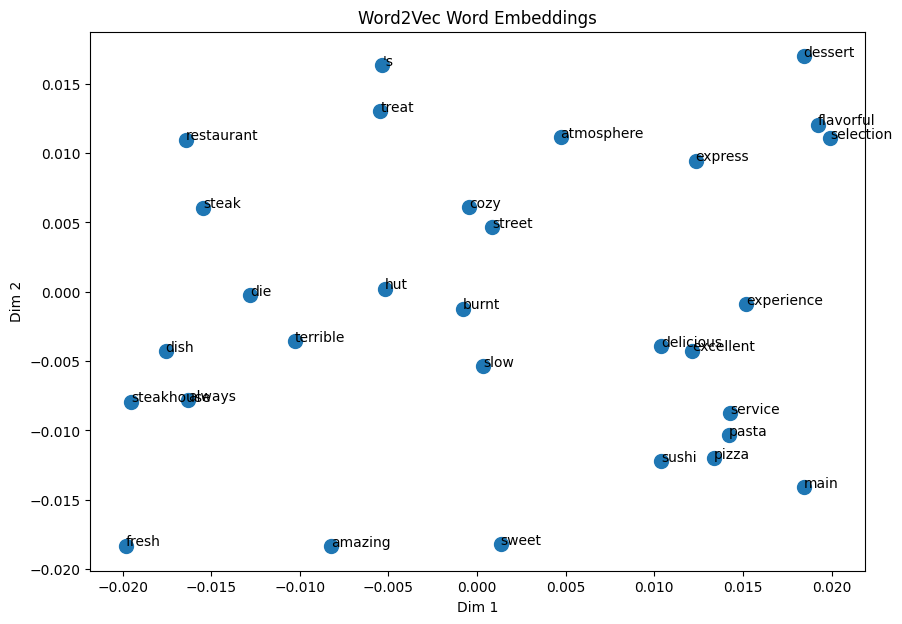

Plot for: large_vectors_window5_skipgram


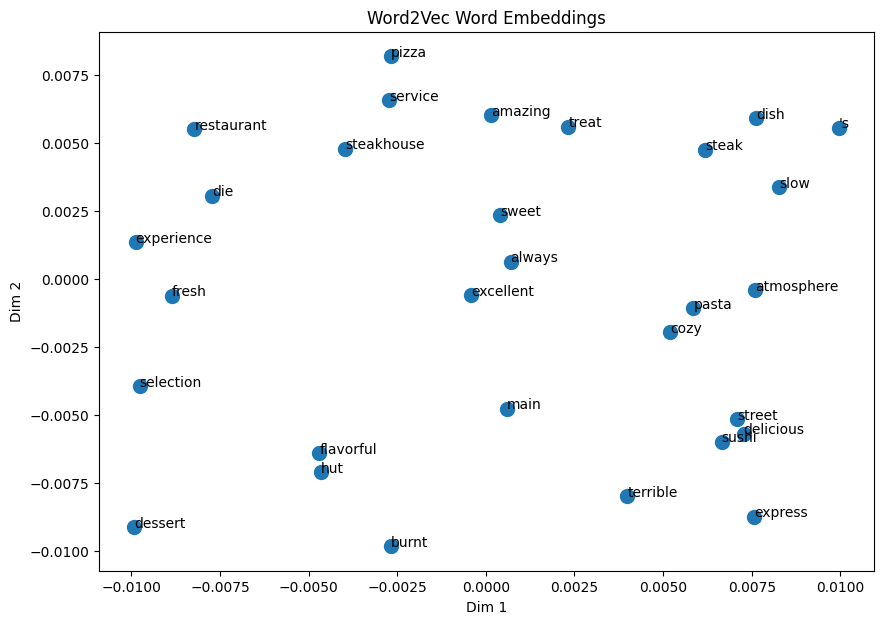

Plot for: small_vectors_window2_cbow


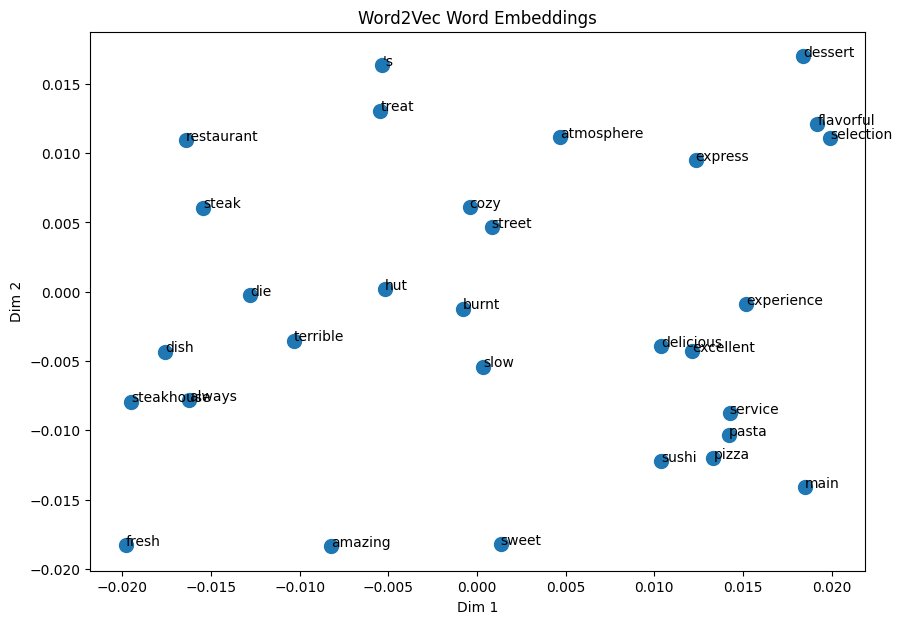

Plot for: large_vectors_window5_cbow


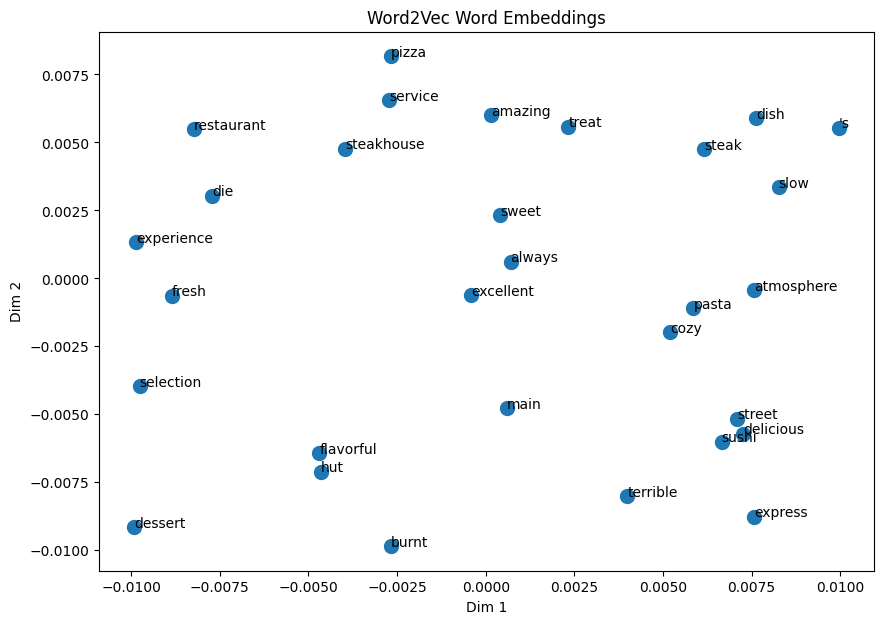

In [40]:
for name, model in models.items():
    print("Plot for:", name)
    plot_word_embeddings(model, words=model.wv.index_to_key[:30])

I trained several Word2Vec models with different vector sizes, window sizes, and training algorithms. Smaller windows focus more on nearby word relationships, while larger windows capture broader context. The plots changed slightly across configurations, but because the dataset is small and only two dimensions are plotted, the clusters are not very strong.

# PCA + t-SNE visualization:

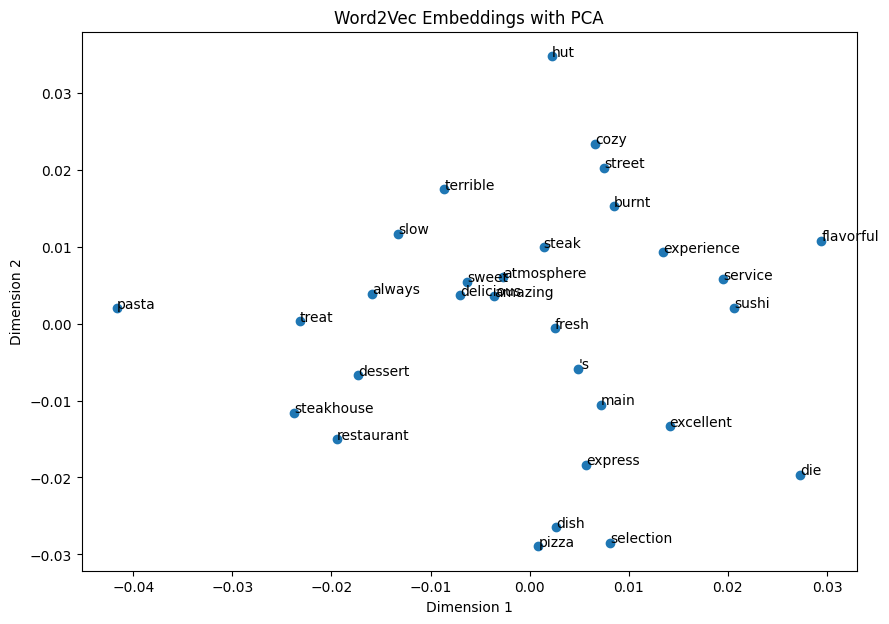

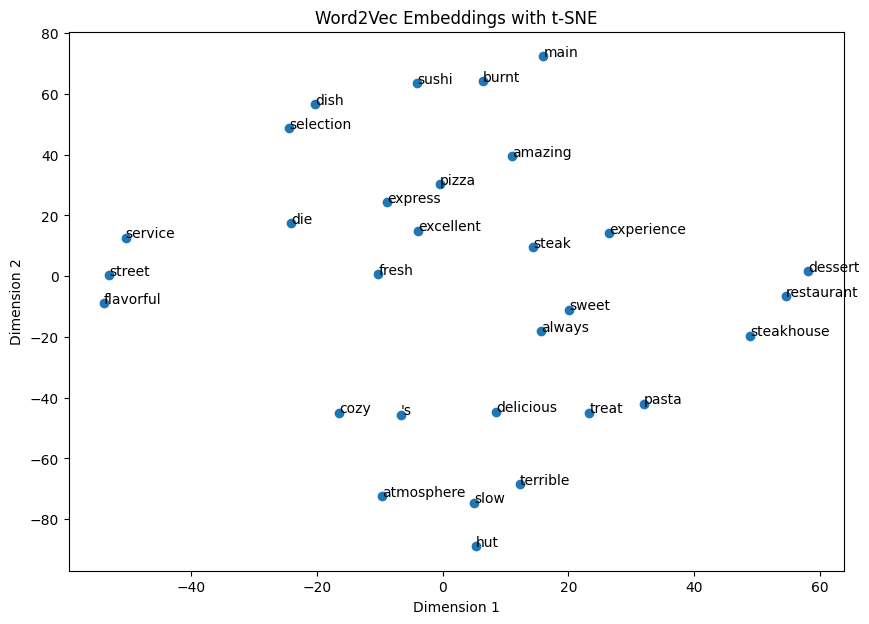

In [41]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

words = w2v_model.wv.index_to_key[:30]
vectors = np.array([w2v_model.wv[word] for word in words])

def plot_reduced_embeddings(reduced_vectors, words, title):
    plt.figure(figsize=(10, 7))
    plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])

    for word, x, y in zip(words, reduced_vectors[:, 0], reduced_vectors[:, 1]):
        plt.annotate(word, (x, y))

    plt.title(title)
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.show()

# PCA
pca = PCA(n_components=2)
pca_vectors = pca.fit_transform(vectors)

plot_reduced_embeddings(
    pca_vectors,
    words,
    "Word2Vec Embeddings with PCA"
)

# t-SNE
perplexity_value = min(5, len(words) - 1)

tsne = TSNE(
    n_components=2,
    perplexity=perplexity_value,
    random_state=42,
    init="random",
    learning_rate="auto"
)

tsne_vectors = tsne.fit_transform(vectors)

plot_reduced_embeddings(
    tsne_vectors,
    words,
    "Word2Vec Embeddings with t-SNE"
)

PCA and t-SNE provide richer visualizations than plotting only the first two embedding dimensions. PCA preserves the main directions of variance, while t-SNE is better for showing local neighborhoods and possible word clusters. In this small dataset, clusters may still be weak, but these methods give a more meaningful 2D view of the full Word2Vec vectors.